# EAGLE3 Configuration Benchmark Analysis

Analyzes results from `scripts/bench_eagle3_configs.py`.

Experiments:
1. **Chain baseline**: topk=1, budget=steps (autoregressive drafting)
2. **Topk sweep**: How branching factor affects performance
3. **Steps sweep**: How tree depth affects performance
4. **Budget sweep**: How total draft tokens affects performance

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 12,
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
})

In [16]:
# Load benchmark results
BENCH_PATH = "../results/qwen3_8b/eagle3_bench.json"  # adjust path as needed

with open(BENCH_PATH) as f:
    data = json.load(f)

vanilla_tpot = data["vanilla_tpot_ms"]
vanilla_tps = data["vanilla_tps"]
df = pd.DataFrame(data["results"])

print(f"Model: {data['model']}")
print(f"Draft: {data['draft_model']}")
print(f"Vanilla TPOT: {vanilla_tpot:.2f} ms/tok, TPS: {vanilla_tps:.1f}")
print(f"Configs: {len(df)}")
print()
df

Model: Qwen/Qwen3-8B
Draft: Tengyunw/qwen3_8b_eagle3
Vanilla TPOT: 20.62 ms/tok, TPS: 48.5
Configs: 16



,topk,steps,budget,mode,tpot_ms,speedup,mat,accept_rate,overall_tps,server_throughput,total_tokens,total_time_s,gpu_util_pct,gpu_mem_mb,gpu_power_w,cpu_util_pct,n_requests,n_accept_samples,error
0,1,1,1,chain,15.93,1.29,1.76,0.7564,62.1,60.7,2048.0,33.0,66.8,21155.0,216.6,3.9,8.0,36.0,NaN
1,1,2,2,chain,13.34,1.55,2.27,0.6338,74.3,72.2,2048.0,27.6,64.5,21176.0,213.2,4.2,8.0,28.0,NaN
2,1,4,4,chain,13.34,1.55,2.84,0.4591,72.8,70.7,2048.0,28.1,55.9,21217.0,199.8,3.7,8.0,22.0,NaN
3,1,8,8,chain,11.56,1.78,3.20,0.2751,82.5,79.9,2048.0,24.8,64.3,21298.0,221.1,3.4,8.0,19.0,NaN
4,1,16,16,chain,14.87,1.39,3.27,0.1420,61.9,60.8,2048.0,33.1,62.7,21477.0,229.8,3.4,8.0,19.0,NaN
5,1,32,32,chain,21.77,0.95,3.31,0.0722,44.4,43.9,2048.0,46.1,64.1,21819.0,232.5,3.4,8.0,19.0,NaN
6,2,3,32,tree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,server_failed
7,4,3,32,tree,9.54,2.16,3.40,0.0748,103.8,98.2,2048.0,19.7,66.9,21218.0,238.1,3.8,8.0,18.0,NaN
8,8,3,32,tree,9.25,2.23,3.51,0.0784,107.1,101.6,2048.0,19.1,67.0,21220.0,239.8,3.9,8.0,18.0,NaN
9,8,2,32,tree,10.75,1.92,2.84,0.0575,91.8,87.8,2048.0,22.3,67.5,21198.0,243.7,3.7,8.0,22.0,NaN


## 1. Overview: All Configurations

In [17]:
# Summary table sorted by speedup
cols = ['mode', 'topk', 'steps', 'budget', 'tpot_ms', 'speedup', 
        'mat', 'accept_rate', 'overall_tps', 'gpu_util_pct']
summary = df[cols].sort_values('speedup', ascending=False)
summary.style.background_gradient(subset=['speedup'], cmap='Greens') \
    .background_gradient(subset=['mat'], cmap='Blues') \
    .format({'speedup': '{:.2f}x', 'tpot_ms': '{:.1f}', 
             'mat': '{:.2f}', 'accept_rate': '{:.3f}',
             'overall_tps': '{:.1f}', 'gpu_util_pct': '{:.0f}%'})

,mode,topk,steps,budget,tpot_ms,speedup,mat,accept_rate,overall_tps,gpu_util_pct
11,tree,8,5,32,8.4,2.46x,4.31,0.104,116.2,64%
10,tree,8,4,32,8.6,2.41x,3.94,0.092,114.0,66%
15,tree,8,3,64,8.9,2.31x,3.62,0.041,111.7,71%
8,tree,8,3,32,9.2,2.23x,3.51,0.078,107.1,67%
14,tree,8,3,16,9.4,2.20x,3.38,0.148,104.2,64%
7,tree,4,3,32,9.5,2.16x,3.40,0.075,103.8,67%
13,tree,8,3,8,9.8,2.09x,3.11,0.264,98.9,65%
9,tree,8,2,32,10.8,1.92x,2.84,0.058,91.8,68%
12,tree,8,3,4,11.5,1.80x,2.71,0.427,85.1,66%
3,chain,1,8,8,11.6,1.78x,3.20,0.275,82.5,64%


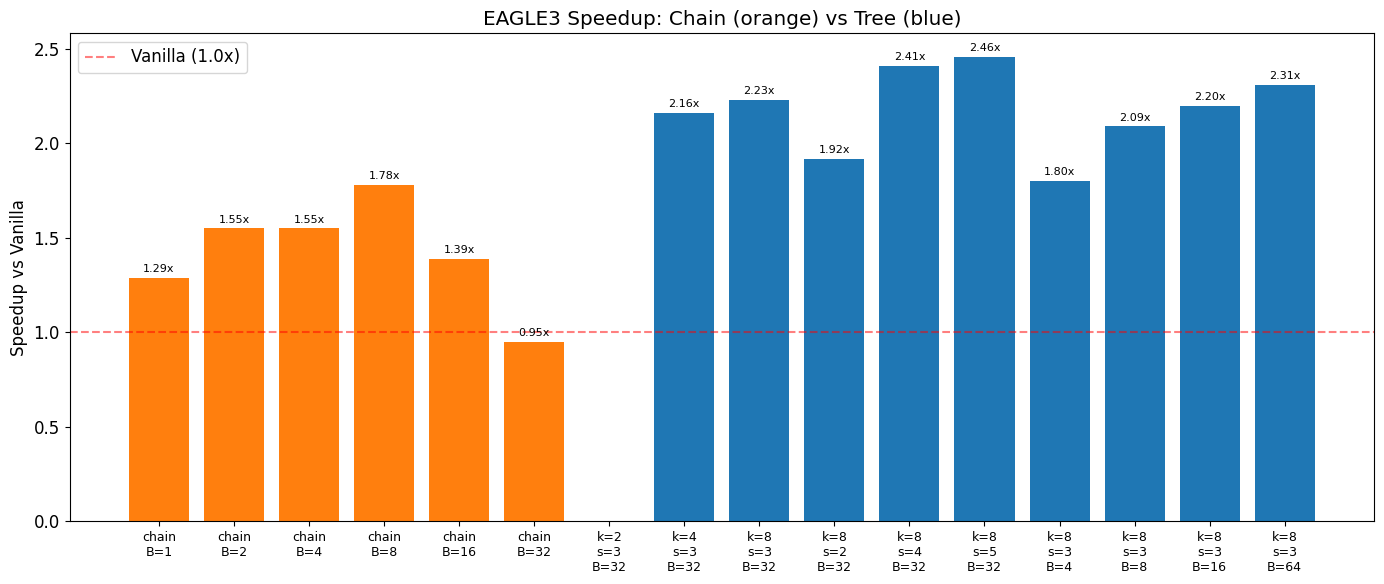

In [18]:
# Bar chart: speedup by config
fig, ax = plt.subplots(figsize=(14, 6))

labels = []
for _, r in df.iterrows():
    if r['mode'] == 'chain':
        labels.append(f"chain\nB={r['budget']}")
    else:
        labels.append(f"k={r['topk']}\ns={r['steps']}\nB={r['budget']}")

colors = ['#ff7f0e' if m == 'chain' else '#1f77b4' for m in df['mode']]
bars = ax.bar(range(len(df)), df['speedup'], color=colors)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title('EAGLE3 Speedup: Chain (orange) vs Tree (blue)')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Vanilla (1.0x)')

for bar, spd in zip(bars, df['speedup']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{spd:.2f}x', ha='center', va='bottom', fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()

## 2. Chain Baseline: Effect of Chain Length

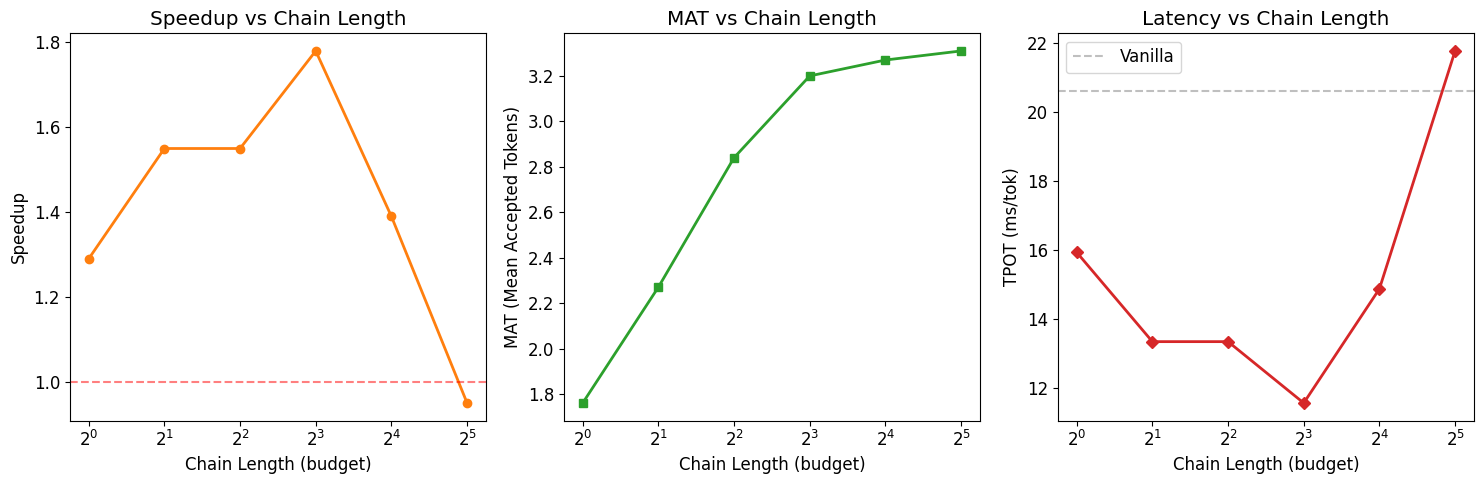

,budget,tpot_ms,speedup,mat,accept_rate,overall_tps
0,1,15.93,1.29,1.76,0.7564,62.1
1,2,13.34,1.55,2.27,0.6338,74.3
2,4,13.34,1.55,2.84,0.4591,72.8
3,8,11.56,1.78,3.20,0.2751,82.5
4,16,14.87,1.39,3.27,0.1420,61.9
5,32,21.77,0.95,3.31,0.0722,44.4


In [19]:
chain = df[df['mode'] == 'chain'].sort_values('budget')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Speedup vs chain length
axes[0].plot(chain['budget'], chain['speedup'], 'o-', color='#ff7f0e', linewidth=2)
axes[0].set_xlabel('Chain Length (budget)')
axes[0].set_ylabel('Speedup')
axes[0].set_title('Speedup vs Chain Length')
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xscale('log', base=2)

# MAT vs chain length
axes[1].plot(chain['budget'], chain['mat'], 's-', color='#2ca02c', linewidth=2)
axes[1].set_xlabel('Chain Length (budget)')
axes[1].set_ylabel('MAT (Mean Accepted Tokens)')
axes[1].set_title('MAT vs Chain Length')
axes[1].set_xscale('log', base=2)

# TPOT breakdown
axes[2].plot(chain['budget'], chain['tpot_ms'], 'D-', color='#d62728', linewidth=2)
axes[2].set_xlabel('Chain Length (budget)')
axes[2].set_ylabel('TPOT (ms/tok)')
axes[2].set_title('Latency vs Chain Length')
axes[2].axhline(y=vanilla_tpot, color='gray', linestyle='--', alpha=0.5, label='Vanilla')
axes[2].legend()
axes[2].set_xscale('log', base=2)

plt.tight_layout()
plt.show()

chain[['budget', 'tpot_ms', 'speedup', 'mat', 'accept_rate', 'overall_tps']]

## 3. Topk Sweep: Effect of Branching Factor

Fixed: steps=3, budget=32. Varying: topk=2,4,8 + chain(topk=1).

In [ ]:
# topk sweep: steps=3, budget=32 (trees only)
topk_sweep = df[
    (df['mode'] == 'tree') & (df['steps'] == 3) & (df['budget'] == 32)
].sort_values('topk').copy()
topk_sweep['step_latency'] = topk_sweep['tpot_ms'] * topk_sweep['mat']

if len(topk_sweep) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].plot(topk_sweep['topk'], topk_sweep['speedup'], 'o-', linewidth=2)
    axes[0].set_xlabel('topk (branching factor)')
    axes[0].set_ylabel('Speedup')
    axes[0].set_title('Speedup vs topk (steps=3, B=32)')
    
    axes[1].plot(topk_sweep['topk'], topk_sweep['mat'], 's-', color='#2ca02c', linewidth=2)
    axes[1].set_xlabel('topk')
    axes[1].set_ylabel('MAT')
    axes[1].set_title('MAT vs topk')
    
    axes[2].plot(topk_sweep['topk'], topk_sweep['step_latency'], 'D-', color='#d62728', linewidth=2)
    axes[2].set_xlabel('topk')
    axes[2].set_ylabel('Step Latency (ms)')
    axes[2].set_title('Step Latency vs topk')
    axes[2].axhline(y=vanilla_tpot, color='gray', linestyle='--', alpha=0.5, label='Vanilla TPOT')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    topk_sweep[['topk', 'steps', 'budget', 'step_latency', 'tpot_ms', 'speedup', 'mat', 'accept_rate']]
else:
    print('No topk sweep data found')

## 4. Steps Sweep: Effect of Tree Depth

Fixed: topk=8, budget=32. Varying: steps=2,3,4,5.

In [ ]:
steps_sweep = df[
    (df['mode'] == 'tree') & (df['topk'] == 8) & (df['budget'] == 32)
].sort_values('steps').copy()
steps_sweep['step_latency'] = steps_sweep['tpot_ms'] * steps_sweep['mat']

if len(steps_sweep) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].plot(steps_sweep['steps'], steps_sweep['speedup'], 'o-', linewidth=2)
    axes[0].set_xlabel('steps (max tree depth)')
    axes[0].set_ylabel('Speedup')
    axes[0].set_title('Speedup vs steps (topk=8, B=32)')
    
    axes[1].plot(steps_sweep['steps'], steps_sweep['mat'], 's-', color='#2ca02c', linewidth=2)
    axes[1].set_xlabel('steps')
    axes[1].set_ylabel('MAT')
    axes[1].set_title('MAT vs steps')
    
    axes[2].plot(steps_sweep['steps'], steps_sweep['step_latency'], 'D-', color='#d62728', linewidth=2)
    axes[2].set_xlabel('steps')
    axes[2].set_ylabel('Step Latency (ms)')
    axes[2].set_title('Step Latency vs steps')
    axes[2].axhline(y=vanilla_tpot, color='gray', linestyle='--', alpha=0.5, label='Vanilla TPOT')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    steps_sweep[['topk', 'steps', 'budget', 'step_latency', 'tpot_ms', 'speedup', 'mat', 'accept_rate']]
else:
    print('No steps sweep data found')

## 5. Budget Sweep: Effect of Total Draft Tokens

Fixed: topk=8, steps=3. Varying: budget=4,8,16,32,64.

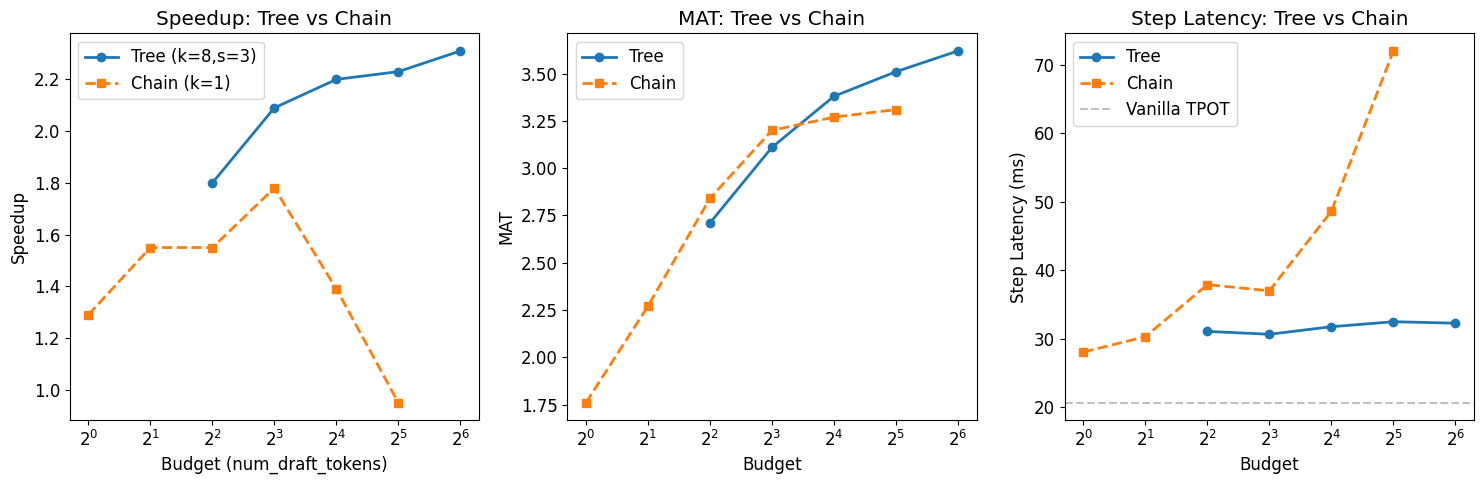

In [22]:
budget_sweep = df[
    (df['mode'] == 'tree') & (df['topk'] == 8) & (df['steps'] == 3)
].sort_values('budget').copy()
budget_sweep['step_latency'] = budget_sweep['tpot_ms'] * budget_sweep['mat']

# Add chain data for comparison
chain_for_compare = df[df['mode'] == 'chain'].sort_values('budget').copy()
chain_for_compare['step_latency'] = chain_for_compare['tpot_ms'] * chain_for_compare['mat']

if len(budget_sweep) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Speedup
    axes[0].plot(budget_sweep['budget'], budget_sweep['speedup'], 'o-', 
                 linewidth=2, label='Tree (k=8,s=3)')
    axes[0].plot(chain_for_compare['budget'], chain_for_compare['speedup'], 's--',
                 color='#ff7f0e', linewidth=2, label='Chain (k=1)')
    axes[0].set_xlabel('Budget (num_draft_tokens)')
    axes[0].set_ylabel('Speedup')
    axes[0].set_title('Speedup: Tree vs Chain')
    axes[0].set_xscale('log', base=2)
    axes[0].legend()
    
    # MAT
    axes[1].plot(budget_sweep['budget'], budget_sweep['mat'], 'o-',
                 linewidth=2, label='Tree')
    axes[1].plot(chain_for_compare['budget'], chain_for_compare['mat'], 's--',
                 color='#ff7f0e', linewidth=2, label='Chain')
    axes[1].set_xlabel('Budget')
    axes[1].set_ylabel('MAT')
    axes[1].set_title('MAT: Tree vs Chain')
    axes[1].set_xscale('log', base=2)
    axes[1].legend()
    
    # Step Latency
    axes[2].plot(budget_sweep['budget'], budget_sweep['step_latency'], 'o-',
                 linewidth=2, label='Tree')
    axes[2].plot(chain_for_compare['budget'], chain_for_compare['step_latency'], 's--',
                 color='#ff7f0e', linewidth=2, label='Chain')
    axes[2].axhline(y=vanilla_tpot, color='gray', linestyle='--', alpha=0.5, label='Vanilla TPOT')
    axes[2].set_xlabel('Budget')
    axes[2].set_ylabel('Step Latency (ms)')
    axes[2].set_title('Step Latency: Tree vs Chain')
    axes[2].set_xscale('log', base=2)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    pd.concat([budget_sweep, chain_for_compare]).sort_values(['budget', 'mode'])[[
        'mode', 'topk', 'steps', 'budget', 'step_latency', 'tpot_ms', 'speedup', 'mat', 'accept_rate'
    ]]
else:
    print('No budget sweep data found')

## 6. Efficiency Analysis: Speedup vs Cost

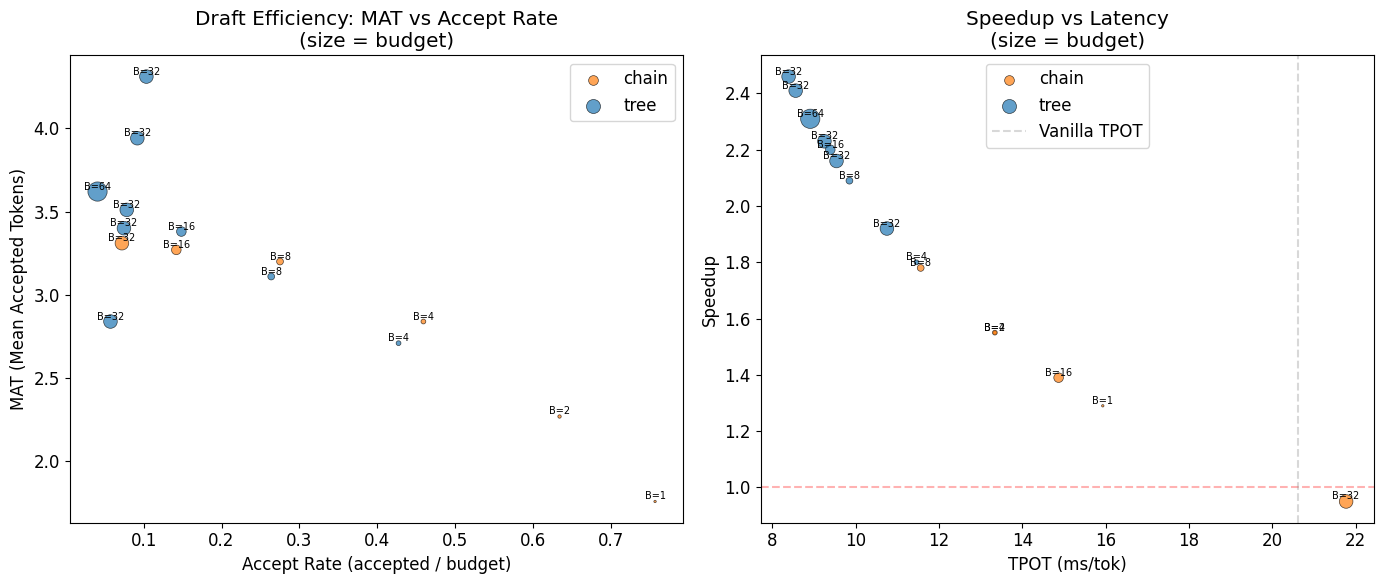

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MAT vs Accept Rate (efficiency of draft tokens)
for mode in ['chain', 'tree']:
    subset = df[df['mode'] == mode]
    color = '#ff7f0e' if mode == 'chain' else '#1f77b4'
    axes[0].scatter(subset['accept_rate'], subset['mat'], 
                    c=color, s=subset['budget'] * 3, alpha=0.7, 
                    label=mode, edgecolors='black', linewidth=0.5)
    for _, r in subset.iterrows():
        axes[0].annotate(f"B={r['budget']}", (r['accept_rate'], r['mat']),
                        fontsize=7, ha='center', va='bottom')

axes[0].set_xlabel('Accept Rate (accepted / budget)')
axes[0].set_ylabel('MAT (Mean Accepted Tokens)')
axes[0].set_title('Draft Efficiency: MAT vs Accept Rate\n(size = budget)')
axes[0].legend()

# Speedup vs TPOT
for mode in ['chain', 'tree']:
    subset = df[df['mode'] == mode]
    color = '#ff7f0e' if mode == 'chain' else '#1f77b4'
    axes[1].scatter(subset['tpot_ms'], subset['speedup'],
                    c=color, s=subset['budget'] * 3, alpha=0.7,
                    label=mode, edgecolors='black', linewidth=0.5)
    for _, r in subset.iterrows():
        axes[1].annotate(f"B={r['budget']}", (r['tpot_ms'], r['speedup']),
                        fontsize=7, ha='center', va='bottom')

axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
axes[1].axvline(x=vanilla_tpot, color='gray', linestyle='--', alpha=0.3, label='Vanilla TPOT')
axes[1].set_xlabel('TPOT (ms/tok)')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Speedup vs Latency\n(size = budget)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. GPU Utilization Analysis

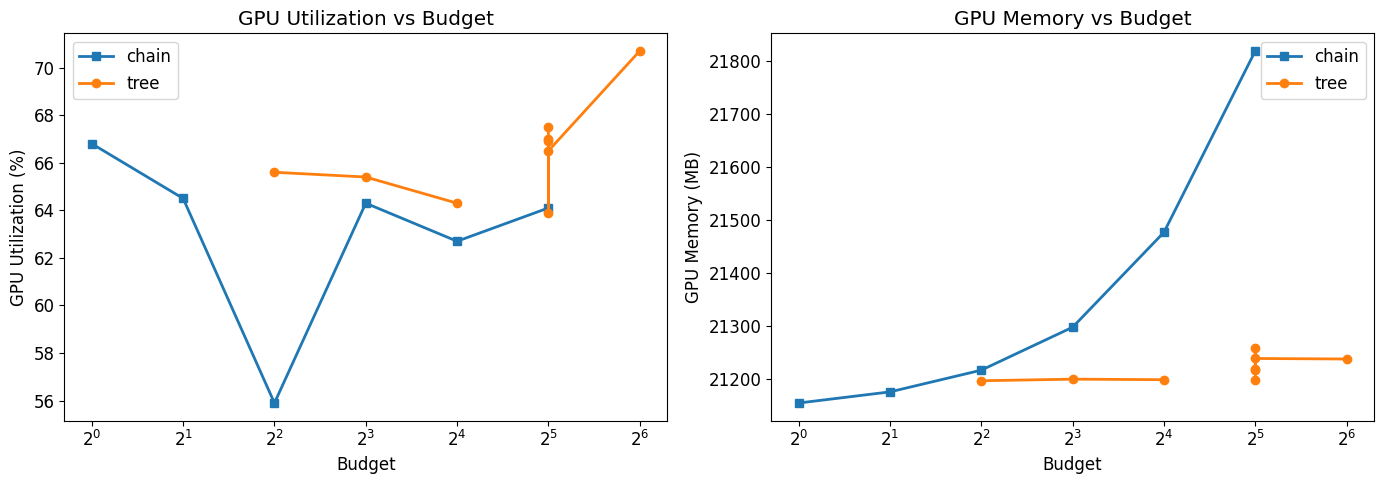

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GPU util vs budget
for mode in ['chain', 'tree']:
    subset = df[df['mode'] == mode].sort_values('budget')
    marker = 's' if mode == 'chain' else 'o'
    axes[0].plot(subset['budget'], subset['gpu_util_pct'], f'{marker}-',
                label=mode, linewidth=2)

axes[0].set_xlabel('Budget')
axes[0].set_ylabel('GPU Utilization (%)')
axes[0].set_title('GPU Utilization vs Budget')
axes[0].set_xscale('log', base=2)
axes[0].legend()

# GPU memory vs budget
for mode in ['chain', 'tree']:
    subset = df[df['mode'] == mode].sort_values('budget')
    marker = 's' if mode == 'chain' else 'o'
    axes[1].plot(subset['budget'], subset['gpu_mem_mb'], f'{marker}-',
                label=mode, linewidth=2)

axes[1].set_xlabel('Budget')
axes[1].set_ylabel('GPU Memory (MB)')
axes[1].set_title('GPU Memory vs Budget')
axes[1].set_xscale('log', base=2)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Calibration data from separate profiling (tree mode, same model/GPU)
calib_budget   = np.array([1,     2,     4,     8,     16,    32,    64])
calib_target   = np.array([21.42, 21.86, 23.63, 22.42, 23.25, 24.06, 23.83])  # target verify
calib_draft    = np.array([4.35,  4.38,  4.70,  4.57,  4.82,  5.21,  5.43])   # tree draft (nearly const)
calib_step     = np.array([31.12, 32.20, 35.34, 35.63, 40.12, 48.76, 97.42])
calib_overhead = calib_step - calib_target - calib_draft

from scipy.interpolate import interp1d
target_fn   = interp1d(calib_budget, calib_target,   kind='linear', fill_value='extrapolate')
overhead_fn = interp1d(calib_budget, calib_overhead,  kind='linear', fill_value='extrapolate')

# Single draft fwd latency (from calibration B=1)
t_draft_single = calib_draft[0]  # ~4.35ms per draft model fwd pass

valid_df = df[df['error'].isna()].copy()
valid_df['step_latency'] = valid_df['tpot_ms'] * valid_df['mat']

# --- Decompose: tree vs chain have different draft models ---
# Target verify: same for both (processes budget tokens in one fwd)
valid_df['target_fwd'] = target_fn(valid_df['budget'])

# Draft:
#   Tree  → fixed steps fwd passes, nearly constant (~4-5ms)
#   Chain → budget sequential fwd passes = budget * t_draft_single
valid_df['eagle3_draft'] = np.where(
    valid_df['mode'] == 'tree',
    interp1d(calib_budget, calib_draft, kind='linear', fill_value='extrapolate')(valid_df['budget']),
    valid_df['budget'] * t_draft_single  # chain: sequential
)

# Overhead = residual
valid_df['overhead'] = valid_df['step_latency'] - valid_df['target_fwd'] - valid_df['eagle3_draft']

# ============================================================
# Plot 1: Chain decomposition
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

chain_df = valid_df[valid_df['mode'] == 'chain'].sort_values('budget')
ax = axes[0]
bottom = np.zeros(len(chain_df))
for col, label, color in [('target_fwd', 'Target verify', '#d62728'),
                           ('eagle3_draft', 'Draft (seq)', '#1f77b4'),
                           ('overhead', 'Overhead', '#aaaaaa')]:
    vals = chain_df[col].values
    ax.bar(range(len(chain_df)), vals, bottom=bottom, label=label, color=color)
    bottom += vals
ax.set_xticks(range(len(chain_df)))
ax.set_xticklabels([f"B={b}" for b in chain_df['budget']])
ax.set_ylabel('Latency (ms)')
ax.set_title('Chain: Step Breakdown\n(draft = B × {:.1f}ms)'.format(t_draft_single))
ax.legend()
for i, (_, r) in enumerate(chain_df.iterrows()):
    ax.text(i, r['step_latency'] + 0.5, f"{r['step_latency']:.0f}", ha='center', fontsize=8)

# ============================================================
# Plot 2: Tree (k=8, s=3) decomposition
# ============================================================
tree_budget = valid_df[(valid_df['mode'] == 'tree') & (valid_df['topk'] == 8) &
                        (valid_df['steps'] == 3)].sort_values('budget')
ax = axes[1]
bottom = np.zeros(len(tree_budget))
for col, label, color in [('target_fwd', 'Target verify', '#d62728'),
                           ('eagle3_draft', 'Draft (tree)', '#1f77b4'),
                           ('overhead', 'Overhead', '#aaaaaa')]:
    vals = tree_budget[col].values
    ax.bar(range(len(tree_budget)), vals, bottom=bottom, label=label, color=color)
    bottom += vals
ax.set_xticks(range(len(tree_budget)))
ax.set_xticklabels([f"B={b}" for b in tree_budget['budget']])
ax.set_ylabel('Latency (ms)')
ax.set_title('Tree (k=8,s=3): Step Breakdown')
ax.legend()
for i, (_, r) in enumerate(tree_budget.iterrows()):
    ax.text(i, r['step_latency'] + 0.5, f"{r['step_latency']:.0f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Summary ---
cols = ['mode', 'topk', 'steps', 'budget', 'step_latency', 'target_fwd', 'eagle3_draft', 'overhead']
print(valid_df[cols].round(2).to_string(index=False))

In [26]:
if 'error' not in df.columns:
    df['error'] = None
valid = df[df['error'].isna()].copy()

best = valid.loc[valid['speedup'].idxmax()]
best_chain = valid[valid['mode'] == 'chain'].loc[valid[valid['mode'] == 'chain']['speedup'].idxmax()]
best_tree = valid[valid['mode'] == 'tree'].loc[valid[valid['mode'] == 'tree']['speedup'].idxmax()]

print("=" * 60)
print("OPTIMAL CONFIGURATIONS")
print("=" * 60)
print(f"\nBest overall: {best['mode']} topk={best['topk']}, steps={best['steps']}, "
      f"budget={best['budget']} → {best['speedup']:.2f}x")
print(f"  TPOT={best['tpot_ms']:.1f}ms, MAT={best['mat']:.2f}, "
      f"accept_rate={best['accept_rate']:.3f}, TPS={best['overall_tps']:.1f}")

print(f"\nBest chain:   topk={best_chain['topk']}, steps={best_chain['steps']}, "
      f"budget={best_chain['budget']} → {best_chain['speedup']:.2f}x")
print(f"  TPOT={best_chain['tpot_ms']:.1f}ms, MAT={best_chain['mat']:.2f}")

print(f"\nBest tree:    topk={best_tree['topk']}, steps={best_tree['steps']}, "
      f"budget={best_tree['budget']} → {best_tree['speedup']:.2f}x")
print(f"  TPOT={best_tree['tpot_ms']:.1f}ms, MAT={best_tree['mat']:.2f}")

print(f"\nTree advantage over chain: "
      f"{(best_tree['speedup'] / best_chain['speedup'] - 1) * 100:+.1f}%")
print("=" * 60)

OPTIMAL CONFIGURATIONS

Best overall: tree topk=8, steps=5, budget=32 → 2.46x
  TPOT=8.4ms, MAT=4.31, accept_rate=0.104, TPS=116.2

Best chain:   topk=1, steps=8, budget=8 → 1.78x
  TPOT=11.6ms, MAT=3.20

Best tree:    topk=8, steps=5, budget=32 → 2.46x
  TPOT=8.4ms, MAT=4.31

Tree advantage over chain: +38.2%


## 9. Per-Category Analysis (from request-level data)

In [ ]:
# Per-category analysis from request-level data
has_per_request = any('per_request' in r for r in data.get('results', []))

if has_per_request:
    rows = []
    for r in data['results']:
        if 'per_request' not in r or 'error' in r:
            continue
        cfg_label = (f"chain B={r['budget']}" if r['mode'] == 'chain'
                     else f"k={r['topk']} s={r['steps']} B={r['budget']}")
        for req in r['per_request']:
            if 'error' in req:
                continue
            rows.append({
                'mode': r['mode'],
                'config': cfg_label,
                'topk': r['topk'],
                'steps': r['steps'],
                'budget': r['budget'],
                'category': req['category'],
                'tpot_ms': req['tpot_ms'],
                'completion_tokens': req['completion_tokens'],
            })
    
    req_df = pd.DataFrame(rows)
    
    # --- Table: per-category TPOT for best configs ---
    cat_summary = req_df.groupby(['config', 'category']).agg(
        tpot_ms=('tpot_ms', 'median'),
        n=('tpot_ms', 'count'),
    ).reset_index()
    
    pivot = cat_summary.pivot(index='config', columns='category', values='tpot_ms').round(1)
    pivot['overall'] = req_df.groupby('config')['tpot_ms'].median().round(1)
    pivot = pivot.sort_values('overall')
    print("Median TPOT (ms/tok) by category:")
    print(pivot.to_string())
    print()
    
    # --- Plot: per-category TPOT for top configs ---
    categories = sorted(req_df['category'].unique())
    # Pick a few interesting configs to compare
    best_tree = df[df['mode'] == 'tree'].dropna(subset=['speedup']).sort_values('speedup', ascending=False).iloc[0]
    best_chain = df[df['mode'] == 'chain'].sort_values('speedup', ascending=False).iloc[0]
    
    selected_configs = []
    for _, r in pd.DataFrame([best_chain, best_tree]).iterrows():
        cfg_label = (f"chain B={int(r['budget'])}" if r['mode'] == 'chain'
                     else f"k={int(r['topk'])} s={int(r['steps'])} B={int(r['budget'])}")
        selected_configs.append(cfg_label)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    sel_df = req_df[req_df['config'].isin(selected_configs)]
    
    if len(sel_df) > 0:
        x = np.arange(len(categories))
        width = 0.8 / len(selected_configs)
        
        for i, cfg in enumerate(selected_configs):
            cfg_data = sel_df[sel_df['config'] == cfg]
            medians = [cfg_data[cfg_data['category'] == c]['tpot_ms'].median() 
                       for c in categories]
            bars = ax.bar(x + i * width, medians, width, label=cfg)
            for j, v in enumerate(medians):
                if pd.notna(v):
                    ax.text(x[j] + i * width, v + 0.2, f'{v:.1f}', 
                            ha='center', va='bottom', fontsize=8)
        
        ax.axhline(y=vanilla_tpot, color='gray', linestyle='--', alpha=0.5, 
                    label=f'Vanilla ({vanilla_tpot:.1f}ms)')
        ax.set_xticks(x + width * (len(selected_configs) - 1) / 2)
        ax.set_xticklabels(categories, rotation=30, ha='right')
        ax.set_ylabel('TPOT (ms/tok)')
        ax.set_title('Per-Category TPOT: Best Chain vs Best Tree')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Selected configs not found in request data")
else:
    print("Per-category breakdown requires per_request data in the JSON.")
    print("Re-run bench (the script now saves per_request data automatically).")

## 10. Raw Data Export

In [28]:
# Export to CSV for external analysis
csv_path = BENCH_PATH.replace('.json', '.csv')
df.to_csv(csv_path, index=False)
print(f"Exported to {csv_path}")
print()
df.to_string()

PermissionError: [Errno 13] Permission denied: '../results/qwen3_8b/eagle3_bench.csv'